In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
import librosa
import numpy as np
import shutil
import hashlib
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
# --- AYARLAR ---
INPUT_DIR = "/kaggle/input/datasets/zuhalaltiner/hamsesler" 
OUTPUT_DIR = "/kaggle/working/Final_Dataset"

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print("🧹 Eski 'Final_Dataset' klasörü ve içindeki tüm hayalet dosyalar silindi!")

klasorler = ["Train_Real", "Train_Fake", "Val_Real", "Val_Fake", "Test_Real", "Test_Fake"]
for k in klasorler:
    os.makedirs(os.path.join(OUTPUT_DIR, k)) # exist_ok=True'yu sildik çünkü zaten sıfırdan kuruyoruz
# ---------------------------------------------------------
# 1. AŞAMA: SES BAZLI MD5 KOPYA AVI 
# ---------------------------------------------------------
print("1. AŞAMA: Ses dalgaları üzerinden MD5 taraması yapılıyor...")
def get_md5(file_path):
    hash_md5 = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()

all_wavs = glob(f"{INPUT_DIR}/**/*.wav", recursive=True)
unique_wavs = []
seen_hashes = set()
labels = []
groups = []

for wav_path in tqdm(all_wavs, desc="Kopyalar Eleniyor"):
    file_hash = get_md5(wav_path)
    
    if file_hash not in seen_hashes:
        seen_hashes.add(file_hash)
        unique_wavs.append(wav_path)
        
        dosya_adi = os.path.basename(wav_path)
        parcalar = dosya_adi.split('_')
        
        etiket = parcalar[0] 
        kisi_id = parcalar[1] 
        
        labels.append(1 if etiket == "FAKE" else 0)
        groups.append(kisi_id)

print(f"\nToplam {len(all_wavs)} sesten {len(unique_wavs)} adet BENZERSİZ ses kaldı!")
print(f"Sistemden uzaklaştırılan sinsi kopya sayısı: {len(all_wavs) - len(unique_wavs)}")

# ---------------------------------------------------------
# 2. AŞAMA: ID'YE GÖRE ZİNCİRLEME BÖLME (TRAIN / VAL / TEST)
# ---------------------------------------------------------
print("\n2. AŞAMA: Sızıntısız Train/Val/Test ayrımı yapılıyor...")

# İndekslemeyi hatasız yapmak için listeleri NumPy dizisine çeviriyoruz
unique_wavs = np.array(unique_wavs)
labels = np.array(labels)
groups = np.array(groups)

# 1. BÖLME: Tüm veriyi -> [Train+Val] ve [Test] olarak ayırıyoruz (Test için %15 ayırıyoruz)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss1.split(unique_wavs, labels, groups))

# [Train+Val] için ayrılan verileri geçici bir diziye alıyoruz
train_val_wavs = unique_wavs[train_val_idx]
train_val_labels = labels[train_val_idx]
train_val_groups = groups[train_val_idx]

# 2. BÖLME: [Train+Val] verisini kendi içinde -> [Train] ve [Val] olarak ayırıyoruz 
# (Kalanın %20'si Val yapılıyor. Bu da toplam verinin yaklaşık %17'sine denk gelir)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss2.split(train_val_wavs, train_val_labels, train_val_groups))

# ---------------------------------------------------------
# 3. AŞAMA: KLASÖRLERE KOPYALAMA
# ---------------------------------------------------------
def dosyalari_kopyala(wav_list, label_list, split_name):
    for kaynak_yol, label in tqdm(zip(wav_list, label_list), total=len(wav_list), desc=f"{split_name} Seti Kopyalanıyor"):
        klasor_tipi = "Real" if label == 0 else "Fake"
        hedef_klasor = os.path.join(OUTPUT_DIR, f"{split_name}_{klasor_tipi}")
        
        shutil.copy2(kaynak_yol, os.path.join(hedef_klasor, os.path.basename(kaynak_yol)))

print("\n3. AŞAMA: Dosyalar ilgili klasörlere kopyalanıyor...")

dosyalari_kopyala(unique_wavs[test_idx], labels[test_idx], "Test")

# Train ve Val setlerini 2. bölünmeden çıkan alt dizilerden kopyala
dosyalari_kopyala(train_val_wavs[train_idx], train_val_labels[train_idx], "Train")
dosyalari_kopyala(train_val_wavs[val_idx], train_val_labels[val_idx], "Val")

print("\n✅ İŞLEM TAMAM! Sızıntısız, kopyasız, zırhlı Train/Val/Test veri setin model eğitimine hazır!")

In [4]:
import glob
train_real = len(glob.glob("/kaggle/working/Final_Dataset/Train_Real/*.wav"))
val_real = len(glob.glob("/kaggle/working/Final_Dataset/Val_Real/*.wav"))
test_real = len(glob.glob("/kaggle/working/Final_Dataset/Test_Real/*.wav"))

train_fake = len(glob.glob("/kaggle/working/Final_Dataset/Train_Fake/*.wav"))
val_fake = len(glob.glob("/kaggle/working/Final_Dataset/Val_Fake/*.wav"))
test_fake = len(glob.glob("/kaggle/working/Final_Dataset/Test_Fake/*.wav"))

total_real = train_real + val_real + test_real
total_fake = train_fake + val_fake + test_fake

print(f"✅ GERÇEK Dosya Sayısı: {total_real}")
print(f"🚨 SAHTE Dosya Sayısı: {total_fake}")
print("-" * 30)
print(f"Genel Toplam: {total_real + total_fake}")

✅ GERÇEK Dosya Sayısı: 642
🚨 SAHTE Dosya Sayısı: 777
------------------------------
Genel Toplam: 1419


## Generator

In [5]:
def min_max_scale(matrix):
    return (matrix - matrix.min()) / (matrix.max() - matrix.min() + 1e-8)
    
class DeepfakeAudioDataset(Dataset):
    def __init__(self, file_paths, labels, dim=(224, 224)):
        self.file_paths = np.array(file_paths)
        self.labels = np.array(labels)
        self.dim = dim
        self.audio_length = 4 * 22050
        

    def __len__(self):
        return len(self.file_paths)

    def pad_dataset(self, data):
        if len(data) > self.audio_length:
            max_offset = len(data) - self.audio_length
            offset = np.random.randint(max_offset)
            data = data[offset:(self.audio_length+offset)]
        else:
            if self.audio_length > len(data):
                max_offset = self.audio_length - len(data)
                offset = np.random.randint(max_offset)
            else:
                offset = 0
            data = np.pad(data, (offset, self.audio_length - len(data) - offset), "constant")
        return data

    def __getitem__(self, index):
        file_path = self.file_paths[index]
        label = self.labels[index]

        # 1. Ses Yükle ve Pad
        audio, sr = librosa.load(file_path, sr=None)
        audio = self.pad_dataset(audio)
        
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_delta = librosa.feature.delta(mfccs)
        mfcc_delta2 = librosa.feature.delta(mfccs, order=2)
        
        # 2. Her birini KENDİ İÇİNDE normalize et
        mfccs_scaled = min_max_scale(mfccs)
        delta_scaled = min_max_scale(mfcc_delta)
        delta2_scaled = min_max_scale(mfcc_delta2)
        
        # 3. R, G ve B kanalları olarak üst üste koy
        stacked_features = np.stack([mfccs_scaled, delta_scaled, delta2_scaled], axis=0)        
        
        # 4. Modelin beklediği boyuta (224x224) getir
        # Numpy dizisini PyTorch Tensor'una çeviriyoruz
        tensor_features = torch.tensor(stacked_features, dtype=torch.float32)
        tensor_features = F.normalize(tensor_features, 
                               mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        resized_features = F.resize(tensor_features, size=self.dim, antialias=True)
        
        # 5. Tekil Tensörleri Dön
        # Etiketi de PyTorch'un sınıflandırma için beklediği "Long" formatına çeviriyoruz
        return resized_features, torch.tensor(label, dtype=torch.float32)

In [6]:
BATCH_SIZE=32
from glob import glob

val_fake = glob("/kaggle/working/Final_Dataset/Val_Fake/*.wav")
val_real = glob("/kaggle/working/Final_Dataset/Val_Real/*.wav")

X_val = val_fake + val_real
y_val = [1] * len(val_fake) + [0] * len(val_real)

train_fake = glob("/kaggle/working/Final_Dataset/Train_Fake/*.wav")
train_real = glob("/kaggle/working/Final_Dataset/Train_Real/*.wav")

X_train = train_fake + train_real
y_train = [1] * len(train_fake) + [0] * len(train_real)

# Veri setlerini oluşturma
train_dataset = DeepfakeAudioDataset(file_paths=X_train, labels=y_train)
val_dataset = DeepfakeAudioDataset(file_paths=X_val, labels=y_val)

# Verileri paketleme (Senin eksiklerini kapatan kısım)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False) # Val için shuffle genelde False yapılır

## Model

In [5]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# 1. ImageNet ağırlıklarıyla hazır modeli yükle
base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# 2. Önceden eğitilmiş ağırlıkları "dondur"
for param in base_model.parameters():
    param.requires_grad = False

# 3. Kendi sınıflandırıcımızı (classifier) inşa edelim
base_model.classifier = nn.Sequential(
    # Keras kodundaki sıraya sadık kalarak:
    nn.Linear(base_model.last_channel, 128), # Dense(128)
    nn.ReLU(),                               # activation='relu'
    nn.Dropout(p=0.3),                       # Dropout(0.3)
    nn.Linear(128, 1)                        # Dense(1) - Sigmoid yok, Loss fonksiyonu halledecek
)

model = base_model.to(device)

Kullanılan cihaz: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 105MB/s] 


In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

# Derleme (Compile) ayarları
criterion = nn.BCEWithLogitsLoss() # binary_crossentropy karşılığı
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001,eps=1e-7)

# Keras: ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5, min_lr=0.00001)

# Keras: EarlyStopping ve ModelCheckpoint için takip değişkenleri
EPOCHS = 30
patience = 10
patience_counter = 0
best_val_loss = float('inf')

print("🚀 Eğitim Başlıyor...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # --- TRAIN (EĞİTİM) ---
    model.train()
    train_loss = 0.0
    
    train_all_preds = []
    train_all_labels = []
    
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        labels = labels.float().unsqueeze(1)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        
        preds = torch.sigmoid(outputs) >= 0.5 
        # DİKKAT: Eğitimdeyken tensörler gradyan (türev) hafızasına bağlıdır. 
        # .detach() kullanarak onu bu hafızadan koparıp CPU'ya alıyoruz.
        train_all_preds.extend(preds.detach().cpu().numpy())
        train_all_labels.extend(labels.cpu().numpy())
        
    train_loss = train_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_all_labels, train_all_preds)
    # --- VALIDATION (DOĞRULAMA) VE METRİKLER ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            labels = labels.float().unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            # Sigmoid'i şimdi tahmin değerlerini 0 ve 1'e çevirmek için kullanıyoruz
            preds = torch.sigmoid(outputs) >= 0.5 
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss = val_loss / len(val_loader.dataset)
    
    # Metrikleri Hesapla (sklearn kullanarak Keras kalitesinde hesaplama)
    val_acc = accuracy_score(all_labels, all_preds)
    val_precision = precision_score(all_labels, all_preds, zero_division=0)
    val_recall = recall_score(all_labels, all_preds, zero_division=0)
    
    print(f"Train Acc: {train_acc:.4f} | Train Loss: {train_loss:.4f} | Precision: {val_precision:.4f}")
    print(f"Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f} | Recall: {val_recall:.4f}")
    
    # --- CALLBACKS MANTIĞI ---
    
    # 1. ReduceLROnPlateau (Öğrenme oranını güncelle)
    scheduler.step(val_loss)
    
    # 2. ModelCheckpoint (Sadece en iyi modeli kaydet)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0 # Sabır sayacını sıfırla
        torch.save(model.state_dict(), 'best_model.pth')
        print("🟢 Yeni en iyi model kaydedildi! (best_model.pth)")
    else:
        patience_counter += 1
        print(f"🟡 Erken durdurma sayacı: {patience_counter}/{patience}")
        
    # 3. EarlyStopping (Erken Durdurma)
    if patience_counter >= patience:
        print(f"🔴 {patience} epoch boyunca val_loss düşmedi. Eğitim erken durduruluyor!")
        break

print("\n✅ Eğitim Süreci Tamamlandı!")

🚀 Eğitim Başlıyor...

Epoch 1/30


Training: 100%|██████████| 31/31 [00:21<00:00,  1.42it/s]


Train Acc: 0.7984 | Train Loss: 0.4538 | Precision: 0.9098
Val Acc: 0.8496 | Val Loss: 0.3743 | Recall: 0.8288
🟢 Yeni en iyi model kaydedildi! (best_model.pth)

Epoch 2/30


Training: 100%|██████████| 31/31 [00:21<00:00,  1.46it/s]


Train Acc: 0.8323 | Train Loss: 0.3669 | Precision: 0.8405
Val Acc: 0.8577 | Val Loss: 0.3581 | Recall: 0.9384
🟢 Yeni en iyi model kaydedildi! (best_model.pth)

Epoch 3/30


...

Train Acc: 0.8971 | Train Loss: 0.2631 | Precision: 0.9110
Val Acc: 0.8943 | Val Loss: 0.3041 | Recall: 0.9110
🟡 Erken durdurma sayacı: 8/10

Epoch 23/30


Training: 100%|██████████| 31/31 [00:21<00:00,  1.43it/s]


Train Acc: 0.9023 | Train Loss: 0.2374 | Precision: 0.9362
Val Acc: 0.9065 | Val Loss: 0.3150 | Recall: 0.9041
🟡 Erken durdurma sayacı: 9/10

Epoch 24/30


Training: 100%|██████████| 31/31 [00:20<00:00,  1.51it/s]


Train Acc: 0.8776 | Train Loss: 0.2685 | Precision: 0.8980
Val Acc: 0.8821 | Val Loss: 0.3199 | Recall: 0.9041
🟡 Erken durdurma sayacı: 10/10
🔴 10 epoch boyunca val_loss düşmedi. Eğitim erken durduruluyor!

✅ Eğitim Süreci Tamamlandı!


## Test 

🚀 Test setinde değerlendirme başlıyor...


Test ediliyor: 100%|██████████| 31/31 [00:23<00:00,  1.30it/s]



--- 📊 TEST SONUÇLARI ---
              precision    recall  f1-score   support

    Real (0)       0.93      0.83      0.88       447
    Fake (1)       0.87      0.95      0.91       525

    accuracy                           0.89       972
   macro avg       0.90      0.89      0.89       972
weighted avg       0.90      0.89      0.89       972



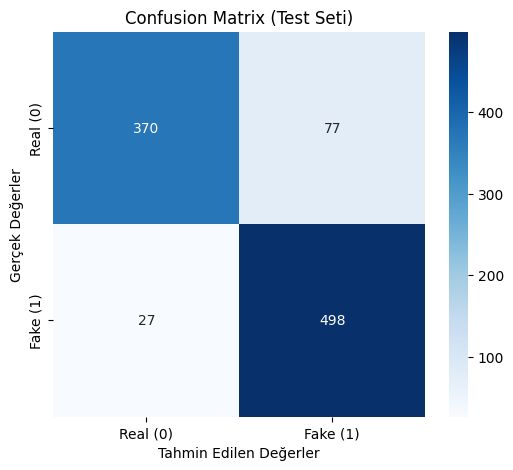

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
# 1. Modelin hiç görmeyeceği Test klasörlerindeki dosyaları buluyoruz
test_fake = glob("/kaggle/working/Final_Dataset/Test_Fake/*.wav")
test_real = glob("/kaggle/working/Final_Dataset/Test_Real/*.wav")

# 2. Dosya yollarını (X) ve etiketleri (y) birleştiriyoruz
X_test = test_fake + test_real
y_test = [1] * len(test_fake) + [0] * len(test_real)

# 3. Test Jeneratörünü hazırlıyoruz 
# (Sırayı bozmuyoruz ve hiçbir dosyayı kaçırmamak için tek tek okutuyoruz)
test_dataset = DeepfakeAudioDataset(file_paths=X_test, labels=y_test)

# Verileri paketleme (Senin eksiklerini kapatan kısım)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = model.to(device)
model.load_state_dict(torch.load('best_model.pth'))
model.eval() # Değerlendirme moduna al (Dropout vb. kapanır)

all_preds = []
all_labels = []

print("🚀 Test setinde değerlendirme başlıyor...")

with torch.no_grad(): # Türev hesaplamayı kapatalım
    for inputs, labels in tqdm(test_loader, desc="Test ediliyor"):
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        # Tahminleri 0 ve 1'e çevir (0.5 eşik değeri)
        preds = torch.sigmoid(outputs) >= 0.5 
        
        # GPU'dan CPU'ya alıp listelere ekle
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 4. Sonuçları Raporlama
print("\n--- 📊 TEST SONUÇLARI ---")
print(classification_report(all_labels, all_preds, target_names=["Real (0)", "Fake (1)"]))

# 5. Confusion Matrix'i Görselleştirme
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Real (0)", "Fake (1)"], 
            yticklabels=["Real (0)", "Fake (1)"])
plt.title("Confusion Matrix (Test Seti)")
plt.ylabel("Gerçek Değerler")
plt.xlabel("Tahmin Edilen Değerler")
plt.show()

# Model Karşılaştırması

### Ortak train ve eval 

In [7]:
test_fake = glob("/kaggle/working/Final_Dataset/Test_Fake/*.wav")
test_real = glob("/kaggle/working/Final_Dataset/Test_Real/*.wav")

# 2. Dosya yollarını (X) ve etiketleri (y) birleştiriyoruz
X_test = test_fake + test_real
y_test = [1] * len(test_fake) + [0] * len(test_real)

# 3. Test Jeneratörünü hazırlıyoruz 
# (Sırayı bozmuyoruz ve hiçbir dosyayı kaçırmamak için tek tek okutuyoruz)
test_dataset = DeepfakeAudioDataset(file_paths=X_test, labels=y_test)

# Verileri paketleme (Senin eksiklerini kapatan kısım)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import copy
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")
# ──────────────────────────────────────────────
# Ortak eğitim/değerlendirme döngüsü
# Tüm modeller bu fonksiyonu kullanır → adil karşılaştırma
# ──────────────────────────────────────────────
def train_and_evaluate(model, model_name, train_loader, val_loader,
                       EPOCHS=50, patience=7, lr=1e-4):
    """
    Herhangi bir PyTorch modelini eğitir, en iyi ağırlıkları kaydeder.
    """
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    # Sadece requires_grad=True olan (donmamış) parametreleri güncelle
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, eps=1e-7
    )
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2,
                                  patience=5, min_lr=1e-5)

    best_val_loss   = float('inf')
    best_weights    = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    start_time = time.time()
    print(f"\n{'='*50}")
    print(f"  {model_name} Eğitimi Başlıyor")
    print(f"{'='*50}")

    for epoch in range(EPOCHS):
        # ── TRAIN ──
        model.train()
        t_loss, t_preds, t_labels = 0.0, [], []

        for inputs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1} Train", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            labels_f = labels.float().unsqueeze(1)

            optimizer.zero_grad()
            loss = criterion(model(inputs), labels_f)
            loss.backward()
            optimizer.step()

            t_loss += loss.item() * inputs.size(0)
            preds   = (torch.sigmoid(model(inputs)) >= 0.5).detach().cpu().numpy()
            t_preds.extend(preds)
            t_labels.extend(labels.cpu().numpy())

        t_loss /= len(train_loader.dataset)
        t_acc   = accuracy_score(t_labels, t_preds)

        # ── VALIDATION ──
        model.eval()
        v_loss, v_preds, v_labels = 0.0, [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                labels_f = labels.float().unsqueeze(1)
                out  = model(inputs)
                v_loss += criterion(out, labels_f).item() * inputs.size(0)
                preds   = (torch.sigmoid(out) >= 0.5).cpu().numpy()
                v_preds.extend(preds)
                v_labels.extend(labels.cpu().numpy())

        v_loss /= len(val_loader.dataset)
        v_acc   = accuracy_score(v_labels, v_preds)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

        scheduler.step(v_loss)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights  = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("  🟢 Yeni en iyi model kaydedildi!")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  🔴 Early stopping ({patience} epoch sabır bitti).")
                break

    elapsed = time.time() - start_time
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f"best_{model_name.replace(' ', '_')}.pth")
    print(f"\n✅ {model_name} tamamlandı. Toplam süre: {elapsed/60:.1f} dk")
    return model, history


def evaluate_on_test(model, model_name, test_loader):
    """Test seti üzerinde kapsamlı metrik hesaplar."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"{model_name} Test"):
            inputs = inputs.to(device)
            out    = model(inputs)
            probs  = torch.sigmoid(out).cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    return {
        "model":     model_name,
        "accuracy":  accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall":    recall_score(all_labels, all_preds, zero_division=0),
        "f1":        f1_score(all_labels, all_preds, zero_division=0),
        "auc_roc":   roc_auc_score(all_labels, all_probs),
        "cm":        confusion_matrix(all_labels, all_preds),
        "report":    classification_report(all_labels, all_preds,
                                           target_names=["Real", "Fake"])
    }

Kullanılan cihaz: cuda


In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_ismi="Model"):
    # Epoch sayısını buluyoruz (Örn: 10 epoch ise x ekseni 1'den 10'a kadar olacak)
    # Not: history sözlüğündeki anahtar isimleri (train_loss vb.) senin train_and_evaluate 
    # fonksiyonunun içine göre değişiklik gösterebilir, gerekirse burayı düzeltiriz.
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Yan yana 2 tane grafik çizeceğimiz geniş bir tuval açıyoruz
    plt.figure(figsize=(14, 5))
    
    # --- 1. GRAFİK: LOSS (Kayıp) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Eğitim (Train) Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r--', label='Doğrulama (Val) Loss', linewidth=2)
    plt.title(f'{model_ismi} - Kayıp (Loss) Grafiği', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # --- 2. GRAFİK: ACCURACY (Doğruluk) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Eğitim (Train) Acc', linewidth=2)
    plt.plot(epochs, history['val_acc'], 'r--', label='Doğrulama (Val) Acc', linewidth=2)
    plt.title(f'{model_ismi} - Doğruluk (Accuracy) Grafiği', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    
    # İndirmek istersen diye resmi kaydediyoruz
    plt.savefig(f"{model_ismi}_egitim_grafikleri.png", dpi=300, bbox_inches='tight')
    plt.show()


## 1. MobileNetV2

In [16]:
def build_mobilenet():
    base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    for p in base.parameters():
        p.requires_grad = False
    base.classifier = nn.Sequential(
        nn.Linear(base.last_channel, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 1)
    )
    return base

mobilenet_model, mobilenet_history = train_and_evaluate(
    build_mobilenet(), "MobileNetV2", train_loader, val_loader
)


  MobileNetV2 Eğitimi Başlıyor


Epoch 01 | Train Loss: 0.5050 Acc: 0.8025 | Val Loss: 0.4030 Acc: 0.8008
  🟢 Yeni en iyi model kaydedildi!


Epoch 02 | Train Loss: 0.4116 Acc: 0.8210 | Val Loss: 0.3832 Acc: 0.8374
  🟢 Yeni en iyi model kaydedildi!


Epoch 03 | Train Loss: 0.3788 Acc: 0.8374 | Val Loss: 0.3184 Acc: 0.8537
  🟢 Yeni en iyi model kaydedildi!


Epoch 04 | Train Loss: 0.3934 Acc: 0.8220 | Val Loss: 0.4112 Acc: 0.7805


...

Epoch 26 | Train Loss: 0.2584 Acc: 0.8940 | Val Loss: 0.2833 Acc: 0.8780


Epoch 27 | Train Loss: 0.2489 Acc: 0.9033 | Val Loss: 0.2745 Acc: 0.8943


Epoch 28 | Train Loss: 0.2746 Acc: 0.8837 | Val Loss: 0.3678 Acc: 0.8415


Epoch 29 | Train Loss: 0.2523 Acc: 0.8879 | Val Loss: 0.3536 Acc: 0.8699


Epoch 30 | Train Loss: 0.2408 Acc: 0.9023 | Val Loss: 0.2813 Acc: 0.8821

✅ MobileNetV2 tamamlandı. Toplam süre: 13.0 dk


In [19]:
evaluate_on_test(mobilenet_model, "MobileNetV2", test_loader)

MobileNetV2 Test: 100%|██████████| 7/7 [00:03<00:00,  1.84it/s]


{'model': 'MobileNetV2',
 'accuracy': 0.8855721393034826,
 'precision': 0.8807339449541285,
 'recall': 0.9056603773584906,
 'f1': 0.8930232558139535,
 'auc_roc': np.float64(0.9506454816285999),
 'cm': array([[82, 13],
        [10, 96]]),
 'report': '              precision    recall  f1-score   support\n\n        Real       0.89      0.86      0.88        95\n        Fake       0.88      0.91      0.89       106\n\n    accuracy                           0.89       201\n   macro avg       0.89      0.88      0.89       201\nweighted avg       0.89      0.89      0.89       201\n'}

## 2. ResNet50 

In [10]:
def build_resnet50():
    base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in base.parameters():
        p.requires_grad = False

    #son katman eğitime açıldı 
    for p in base.layer4.parameters():
        p.requires_grad = True
    # Son katmanı değiştir
    # resnet50.fc: Linear(2048 → 1000) → bizim başlığımızla değiştir
    in_features = base.fc.in_features          # 2048
    base.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 1)
    )
    return base

resnet_model, resnet_history = train_and_evaluate(
    build_resnet50(), "ResNet50", train_loader, val_loader
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]



  ResNet50 Eğitimi Başlıyor


KeyboardInterrupt: 

In [20]:
evaluate_on_test(resnet_model, "ResNet50", test_loader)

ResNet50 Test: 100%|██████████| 7/7 [00:03<00:00,  1.85it/s]


{'model': 'ResNet50',
 'accuracy': 0.945273631840796,
 'precision': 0.9523809523809523,
 'recall': 0.9433962264150944,
 'f1': 0.9478672985781991,
 'auc_roc': np.float64(0.9868917576961271),
 'cm': array([[ 90,   5],
        [  6, 100]]),
 'report': '              precision    recall  f1-score   support\n\n        Real       0.94      0.95      0.94        95\n        Fake       0.95      0.94      0.95       106\n\n    accuracy                           0.95       201\n   macro avg       0.94      0.95      0.95       201\nweighted avg       0.95      0.95      0.95       201\n'}

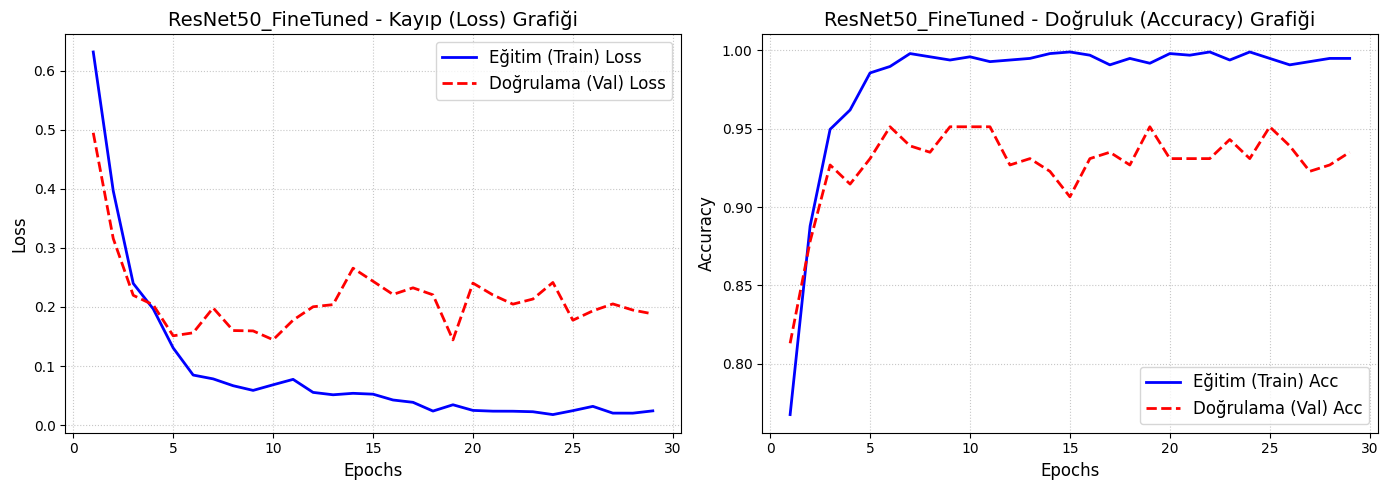

In [28]:
plot_training_history(resnet_history, model_ismi="ResNet50_FineTuned")

## 3. ResNeXt50

In [22]:
def build_resnext50():
    # groups=32, width=4 → ResNeXt50_32x4d
    base = models.resnext50_32x4d(
        weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2
    )
    for p in base.parameters():
        p.requires_grad = False

    for p in base.layer4.parameters():
        p.requires_grad = True

    
    in_features = base.fc.in_features          # 2048
    base.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 1)
    )
    return base

resnext_model, resnext_history = train_and_evaluate(
    build_resnext50(), "ResNeXt50", train_loader, val_loader
)

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 232MB/s]



  ResNeXt50 Eğitimi Başlıyor


Epoch 01 | Train Loss: 0.5935 Acc: 0.8189 | Val Loss: 0.4232 Acc: 0.8293
  🟢 Yeni en iyi model kaydedildi!


Epoch 02 | Train Loss: 0.3718 Acc: 0.8765 | Val Loss: 0.3239 Acc: 0.8415
  🟢 Yeni en iyi model kaydedildi!


...

Epoch 17 | Train Loss: 0.0227 Acc: 1.0000 | Val Loss: 0.2188 Acc: 0.9350


Epoch 18 | Train Loss: 0.0297 Acc: 0.9959 | Val Loss: 0.2191 Acc: 0.9472


Epoch 19 | Train Loss: 0.0076 Acc: 1.0000 | Val Loss: 0.2366 Acc: 0.9350


Epoch 20 | Train Loss: 0.0312 Acc: 0.9938 | Val Loss: 0.2496 Acc: 0.9390


Epoch 21 | Train Loss: 0.0274 Acc: 0.9949 | Val Loss: 0.2148 Acc: 0.9512
  🔴 Early stopping (10 epoch sabır bitti).

✅ ResNeXt50 tamamlandı. Toplam süre: 12.0 dk


In [25]:
evaluate_on_test(resnext_model, "ResNeXt50", test_loader)

ResNeXt50 Test: 100%|██████████| 7/7 [00:04<00:00,  1.62it/s]


{'model': 'ResNeXt50',
 'accuracy': 0.9552238805970149,
 'precision': 0.9801980198019802,
 'recall': 0.9339622641509434,
 'f1': 0.9565217391304348,
 'auc_roc': np.float64(0.9846077457795432),
 'cm': array([[93,  2],
        [ 7, 99]]),
 'report': '              precision    recall  f1-score   support\n\n        Real       0.93      0.98      0.95        95\n        Fake       0.98      0.93      0.96       106\n\n    accuracy                           0.96       201\n   macro avg       0.96      0.96      0.96       201\nweighted avg       0.96      0.96      0.96       201\n'}

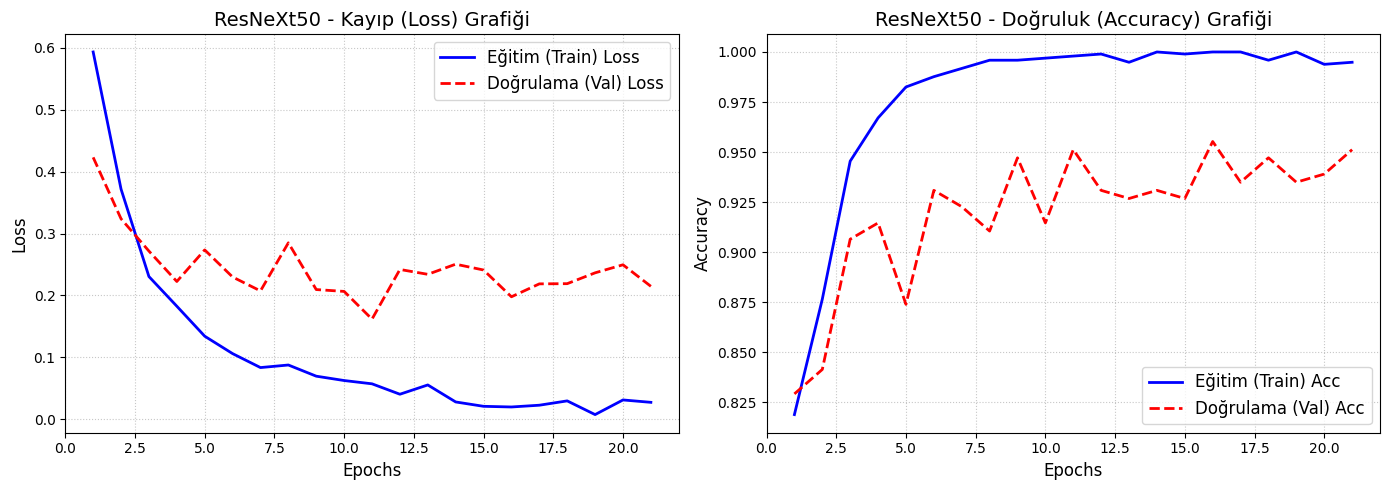

In [26]:
plot_training_history(resnext_history, model_ismi="ResNeXt50")

## 4. EfficientNet-B3

In [9]:
def build_efficientnet_b3():
    base = models.efficientnet_b3(
        weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
    )
    for p in base.parameters():
        p.requires_grad = False

    for p in base.features[-2:].parameters():
        p.requires_grad = True
    """
    # EfficientNet'in classifier'ı: Sequential([Dropout, Linear(1536→1000)])
    # Biz sadece Linear kısmını değiştiriyoruz, Dropout zaten var
    in_features = base.classifier[1].in_features   # 1536
    base.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 256),
        nn.SiLU(),          # EfficientNet'in Swish aktivasyonu (SiLU ≈ Swish)
        nn.Dropout(0.4),
        nn.Linear(256, 1)
    )
    return base
    """
    in_features = base.classifier[1].in_features  # 1536
    base.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),  # sadece orijinali koru
        nn.Linear(in_features, 1)         # direkt çıkışa git, ara katman yok
    )
    return base

effnet_model, effnet_history = train_and_evaluate(
    build_efficientnet_b3(), "EfficientNet-B3", train_loader, val_loader
)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 199MB/s]



  EfficientNet-B3 Eğitimi Başlıyor


Epoch 01 | Train Loss: 0.6333 Acc: 0.7099 | Val Loss: 0.5557 Acc: 0.8008
  🟢 Yeni en iyi model kaydedildi!


Epoch 02 | Train Loss: 0.5114 Acc: 0.8097 | Val Loss: 0.4551 Acc: 0.8130
  🟢 Yeni en iyi model kaydedildi!


...

Epoch 15 | Train Loss: 0.1769 Acc: 0.9516 | Val Loss: 0.2630 Acc: 0.9024


Epoch 16 | Train Loss: 0.1820 Acc: 0.9434 | Val Loss: 0.2499 Acc: 0.8902


Epoch 17 | Train Loss: 0.1516 Acc: 0.9342 | Val Loss: 0.2209 Acc: 0.9024


Epoch 18 | Train Loss: 0.1503 Acc: 0.9455 | Val Loss: 0.2347 Acc: 0.9065


Epoch 19 | Train Loss: 0.1639 Acc: 0.9342 | Val Loss: 0.2700 Acc: 0.8984
  🔴 Early stopping (7 epoch sabır bitti).

✅ EfficientNet-B3 tamamlandı. Toplam süre: 8.9 dk


In [11]:
evaluate_on_test(effnet_model, "EfficientNet-B3", test_loader)

EfficientNet-B3 Test: 100%|██████████| 7/7 [00:03<00:00,  1.78it/s]


{'model': 'EfficientNet-B3',
 'accuracy': 0.9203980099502488,
 'precision': 0.9166666666666666,
 'recall': 0.9339622641509434,
 'f1': 0.9252336448598131,
 'auc_roc': np.float64(0.9694141012909633),
 'cm': array([[86,  9],
        [ 7, 99]]),
 'report': '              precision    recall  f1-score   support\n\n        Real       0.92      0.91      0.91        95\n        Fake       0.92      0.93      0.93       106\n\n    accuracy                           0.92       201\n   macro avg       0.92      0.92      0.92       201\nweighted avg       0.92      0.92      0.92       201\n'}

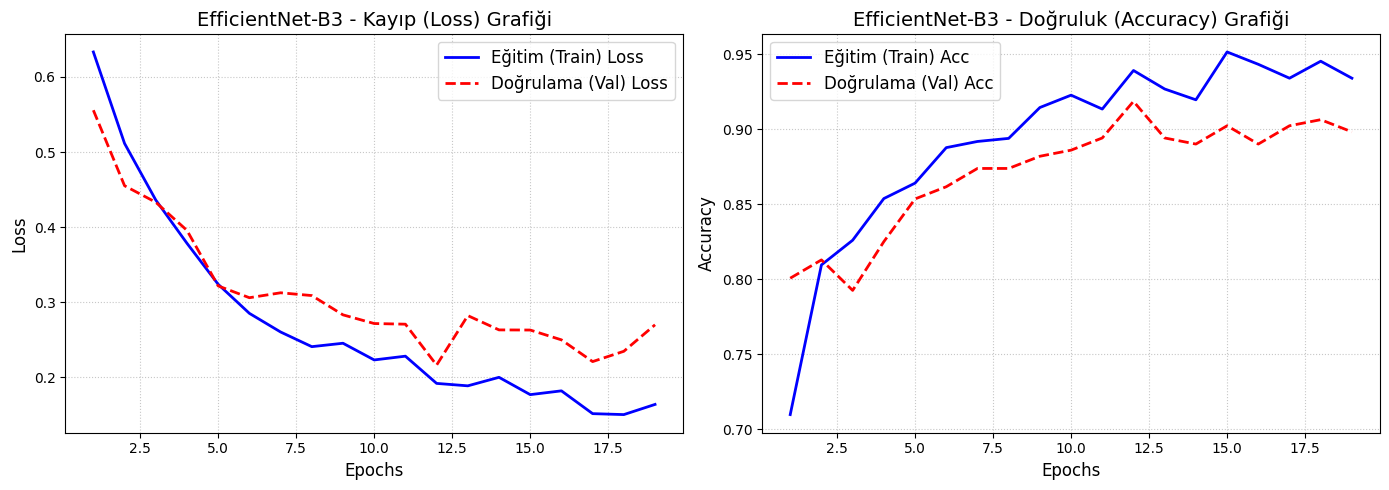

In [10]:
plot_training_history(effnet_history, model_ismi="EfficientNet-B3")

## 5. DenseNet121

In [36]:
def build_densenet121():
    base = models.densenet121(
        weights=models.DenseNet121_Weights.IMAGENET1K_V1
    )
    for p in base.parameters():
        p.requires_grad = False

    # 2. STRATEJİK AÇILIŞ: DenseNet'in son bloğunu (denseblock4) ve norm5'i açıyoruz
    for p in base.features.denseblock4.parameters():
        p.requires_grad = True
        
    for p in base.features.norm5.parameters():
        p.requires_grad = True
        
    # DenseNet'in son katmanı: base.classifier → Linear(1024, 1000)
    in_features = base.classifier.in_features   # 1024
    base.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, 1)
    )
    return base

densenet_model, densenet_history = train_and_evaluate(
    build_densenet121(), "DenseNet121", train_loader, val_loader
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 187MB/s]



  DenseNet121 Eğitimi Başlıyor


Epoch 01 | Train Loss: 0.5604 Acc: 0.7623 | Val Loss: 0.4373 Acc: 0.8089
  🟢 Yeni en iyi model kaydedildi!


Epoch 02 | Train Loss: 0.3898 Acc: 0.8333 | Val Loss: 0.3446 Acc: 0.8618
  🟢 Yeni en iyi model kaydedildi!


...

Epoch 13 | Train Loss: 0.0588 Acc: 0.9846 | Val Loss: 0.1618 Acc: 0.9472


Epoch 14 | Train Loss: 0.0407 Acc: 0.9928 | Val Loss: 0.1324 Acc: 0.9512


Epoch 15 | Train Loss: 0.0527 Acc: 0.9887 | Val Loss: 0.1629 Acc: 0.9390


Epoch 16 | Train Loss: 0.0503 Acc: 0.9949 | Val Loss: 0.1584 Acc: 0.9390


Epoch 17 | Train Loss: 0.0372 Acc: 0.9887 | Val Loss: 0.1654 Acc: 0.9431
  🔴 Early stopping (7 epoch sabır bitti).

✅ DenseNet121 tamamlandı. Toplam süre: 7.9 dk


In [37]:
evaluate_on_test(densenet_model, "DenseNet121", test_loader)

DenseNet121 Test: 100%|██████████| 7/7 [00:03<00:00,  1.79it/s]


{'model': 'DenseNet121',
 'accuracy': 0.9552238805970149,
 'precision': 0.9532710280373832,
 'recall': 0.9622641509433962,
 'f1': 0.9577464788732394,
 'auc_roc': np.float64(0.992651439920556),
 'cm': array([[ 90,   5],
        [  4, 102]]),
 'report': '              precision    recall  f1-score   support\n\n        Real       0.96      0.95      0.95        95\n        Fake       0.95      0.96      0.96       106\n\n    accuracy                           0.96       201\n   macro avg       0.96      0.95      0.96       201\nweighted avg       0.96      0.96      0.96       201\n'}

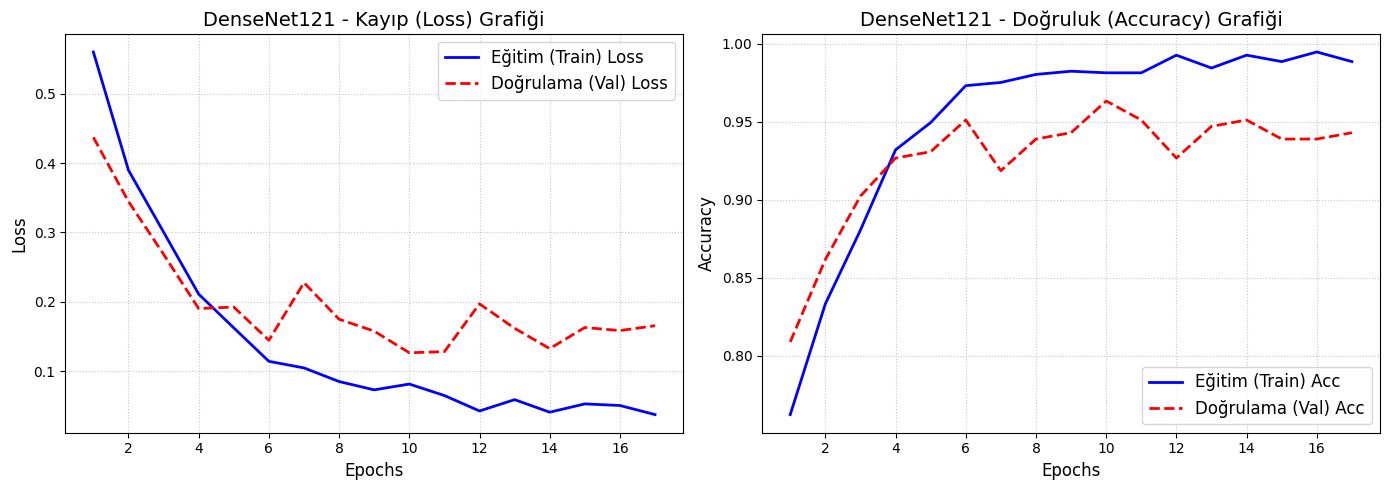

In [38]:
plot_training_history(densenet_history, model_ismi="DenseNet121")

## 📊 Karşılaştırma — Test Seti Metrikleri

In [ ]:
# Test loader'ı oluşturuyoruz (mevcut kodunuzdaki gibi)
from glob import glob
from torch.utils.data import DataLoader

test_fake = glob("/kaggle/working/Final_Dataset/Test_Fake/*.wav")
test_real = glob("/kaggle/working/Final_Dataset/Test_Real/*.wav")
X_test = test_fake + test_real
y_test = [1] * len(test_fake) + [0] * len(test_real)

test_dataset = DeepfakeAudioDataset(file_paths=X_test, labels=y_test)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ─── Tüm modelleri test et ───
all_models = [
    (mobilenet_model,  "MobileNetV2"),
    (resnet_model,     "ResNet50"),
    (resnext_model,    "ResNeXt50"),
    (effnet_model,     "EfficientNet-B3"),
    (xception_model,   "XceptionNet"),
    (densenet_model,   "DenseNet121"),
    (convnext_model,   "ConvNeXt-Tiny"),
]

results = []
for model, name in all_models:
    r = evaluate_on_test(model, name, test_loader)
    results.append(r)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(r["report"])